In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置绘图风格
sns.set_theme(style="whitegrid")
# 解决 matplotlib 中文显示问题（如有需要）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

In [2]:
output_dir = 'output'
all_csv_files = [f for f in os.listdir(output_dir) if f.endswith('.csv') and f != 'merged_labels.csv']

df_list = []
for file in all_csv_files:
    file_path = os.path.join(output_dir, file)
    temp_df = pd.read_csv(file_path)
    df_list.append(temp_df)

if df_list:
    # 合并所有数据框
    merged_df = pd.concat(df_list, ignore_index=True)
    
    # 保存合并后的结果
    merged_path = os.path.join(output_dir, 'merged_labels.csv')
    merged_df.to_csv(merged_path, index=False, encoding='utf-8')
    print(f"成功合并 {len(all_csv_files)} 个文件，总计 {len(merged_df)} 条记录。")
    print(f"合并后的文件已保存至: {merged_path}")
else:
    print("未在 output 文件夹中找到可合并的 CSV 文件。")

成功合并 3 个文件，总计 6529 条记录。
合并后的文件已保存至: output\merged_labels.csv


baitaishe      4919
liewenshe      1654
hongshe        1435
hongdianshe    1228
huangtaishe    1109
chihenshe      1053
pangdashe       684
shenquao        482
botaishe        392
xinfeiao        368
shoushe         283
huataishe       242
zishe           230
gandanao        189
piweiao         178
heitaishe       121
jiankangshe      19
gandantu          5
shenqutu          2
xinfeitu          2
piweitu           0
dtype: int64


C:\Users\13529\AppData\Local\Temp\ipykernel_9648\2434465089.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="magma")


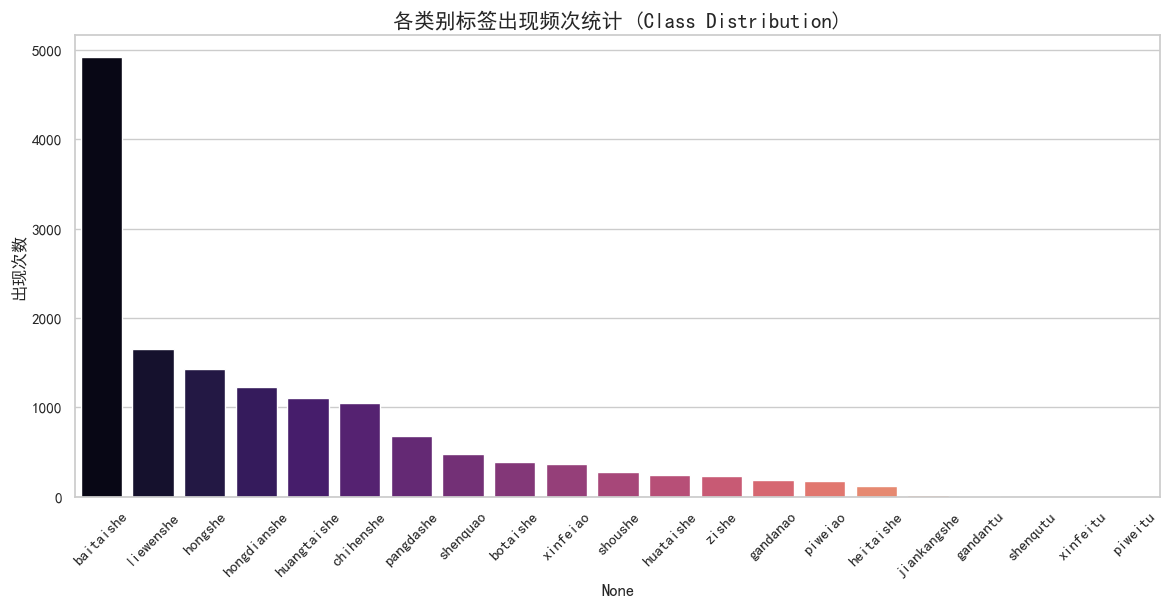

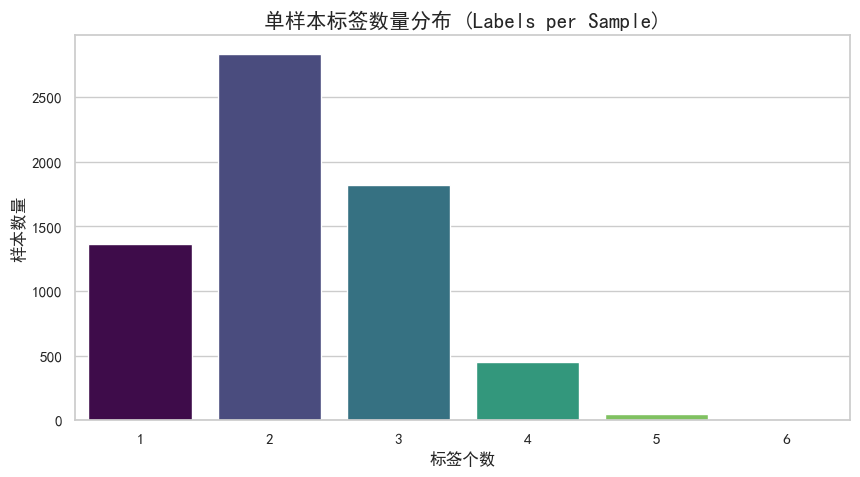

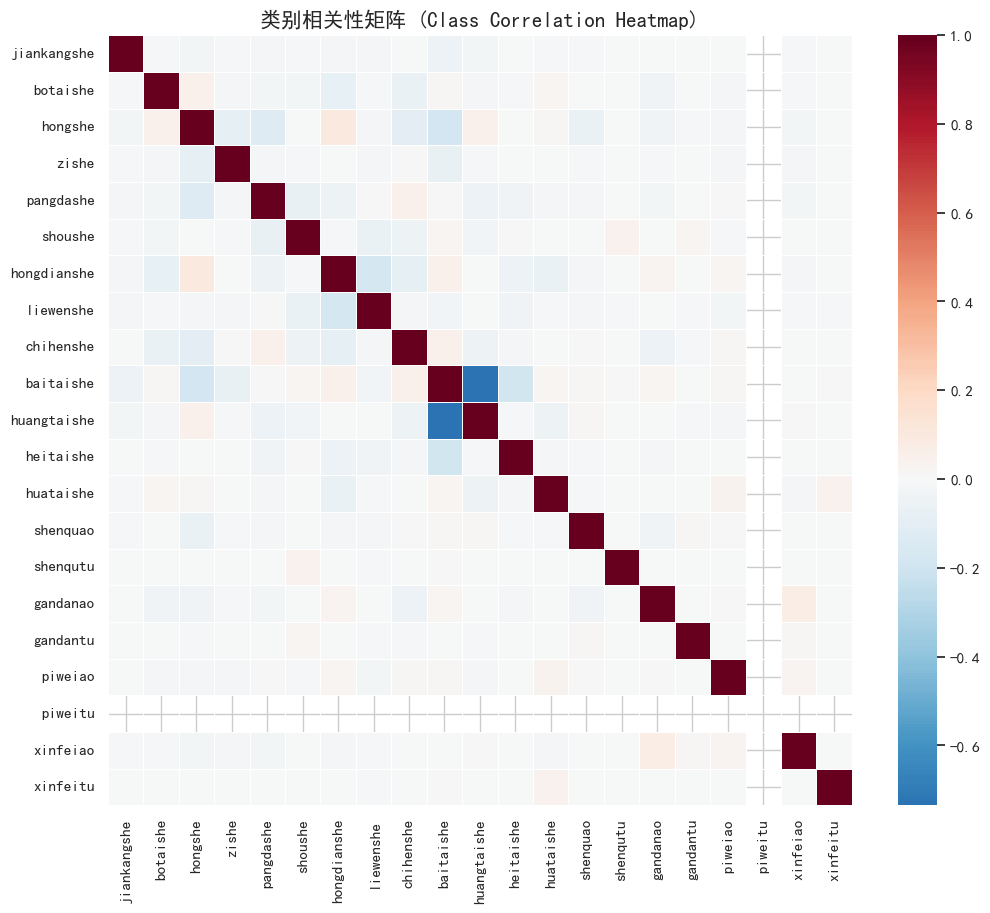

【数据探索摘要】
最常见的标签: baitaishe (4919次)
最罕见的标签: piweitu (0次)
平均每张图片携带标签数: 2.24


In [8]:
# 确保使用合并后的数据
df = pd.read_csv(os.path.join(output_dir, 'merged_labels.csv'))

# 1. 准备数据：提取标签列（排除 filename 列）
label_cols = [c for c in df.columns if c != 'filename']
label_data = df[label_cols]

# --- 维度 A: 类别频率分析 ---
class_counts = label_data.sum().sort_values(ascending=False)
print(class_counts)

plt.figure(figsize=(14, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="magma")
plt.title("各类别标签出现频次统计 (Class Distribution)", fontsize=15)
plt.ylabel("出现次数")
plt.xticks(rotation=45)
plt.show()

# --- 维度 B: 标签密度分析 (每张图含有多少个标签) ---
labels_per_img = label_data.sum(axis=1)

plt.figure(figsize=(10, 5))
sns.countplot(x=labels_per_img, hue=labels_per_img, palette="viridis", legend=False)
plt.title("单样本标签数量分布 (Labels per Sample)", fontsize=15)
plt.xlabel("标签个数")
plt.ylabel("样本数量")
plt.show()

# --- 维度 C: 类别相关性热图 ---
# 观察哪些病症（标签）经常同时出现
plt.figure(figsize=(12, 10))
corr = label_data.corr()
mask = (corr == 0) # 掩盖无相关性的部分
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, linewidths=0.5)
plt.title("类别相关性矩阵 (Class Correlation Heatmap)", fontsize=15)
plt.show()

# 打印简单摘要
print("【数据探索摘要】")
print(f"最常见的标签: {class_counts.index[0]} ({class_counts.iloc[0]}次)")
print(f"最罕见的标签: {class_counts.index[-1]} ({class_counts.iloc[-1]}次)")
print(f"平均每张图片携带标签数: {labels_per_img.mean():.2f}")

In [4]:
label_columns = [
    'jiankangshe', 'botaishe', 'hongshe', 'zishe', 'pangdashe', 'shoushe', 
    'hongdianshe', 'liewenshe', 'chihenshe', 'baitaishe', 'huangtaishe', 
    'heitaishe', 'huataishe', 'shenquao', 'shenqutu', 'gandanao', 
    'gandantu', 'piweiao', 'piweitu', 'xinfeiao', 'xinfeitu'
]

# 1. 健康舌互斥验证
# 逻辑：jiankangshe == 1 时，sum(others) 应该等于 0
others = label_columns[1:]
violation_healthy = df[df['jiankangshe'] == 1][others].sum(axis=1) > 0

print(f"--- 健康舌互斥性检查 ---")
print(f"健康舌样本总数: {df['jiankangshe'].sum()}")
print(f"违反逻辑样本数 (健康舌同时标注了其他特征): {violation_healthy.sum()}")
if violation_healthy.sum() > 0:
    print(f"违规样本索引示例: {df[df['jiankangshe'] == 1][violation_healthy].index.tolist()[:5]}")

--- 健康舌互斥性检查 ---
健康舌样本总数: 19
违反逻辑样本数 (健康舌同时标注了其他特征): 7
违规样本索引示例: [1011, 1786, 2537, 4306, 6046]


In [5]:
# 2. 检查是否有“无标签”样本
# 逻辑：sum(all_labels) 应该 >= 1
total_sum = df[label_columns].sum(axis=1)
no_label_samples = (total_sum == 0)

print(f"--- 标签完整性检查 ---")
print(f"完全没有标签的样本数: {no_label_samples.sum()}")
# 逻辑：如果其余 20 个标签均为 0，是否被标记为了健康舌？
unmarked_sick = (df[others].sum(axis=1) == 0) & (df['jiankangshe'] == 0)
print(f"未标症状且未标健康的‘孤儿’样本数: {unmarked_sick.sum()}")

--- 标签完整性检查 ---
完全没有标签的样本数: 0
未标症状且未标健康的‘孤儿’样本数: 0


In [6]:
# 3. 舌质颜色互斥
# 这里我们检查红舌(2)和紫舌(3)
color_clash = (df['hongshe'] == 1) & (df['zishe'] == 1)

# 4. 舌苔颜色互斥
# 检查白苔(9)、黄苔(10)、黑苔(11)的共存
coating_colors = ['baitaishe', 'huangtaishe', 'heitaishe']
multiple_coating_colors = df[coating_colors].sum(axis=1) > 1

print(f"--- 颜色互斥检查 ---")
print(f"同时标注红舌和紫舌的样本: {color_clash.sum()}")
print(f"同时标注多种苔色的样本: {multiple_coating_colors.sum()}")

# 进阶验证：每张图是否至少有一种颜色（色/苔）？
# 注意：有些数据可能默认淡红舌不标，需根据你的数据集规范调整

--- 颜色互斥检查 ---
同时标注红舌和紫舌的样本: 6
同时标注多种苔色的样本: 96


In [7]:
# 5. 胖瘦互斥
shape_clash = (df['pangdashe'] == 1) & (df['shoushe'] == 1)

# 6. 区域凹凸互斥
regions = [
    ('shenquao', 'shenqutu'), 
    ('gandanao', 'gandantu'), 
    ('piweiao', 'piweitu'), 
    ('xinfeiao', 'xinfeitu')
]

print(f"--- 形态与区域互斥检查 ---")
print(f"同时胖大又消瘦的违规样本: {shape_clash.sum()}")

for ao, tu in regions:
    clash = (df[ao] == 1) & (df[tu] == 1)
    print(f"区域 {ao}/{tu} 同时凹凸违规数: {clash.sum()}")

--- 形态与区域互斥检查 ---
同时胖大又消瘦的违规样本: 0
区域 shenquao/shenqutu 同时凹凸违规数: 0
区域 gandanao/gandantu 同时凹凸违规数: 0
区域 piweiao/piweitu 同时凹凸违规数: 0
区域 xinfeiao/xinfeitu 同时凹凸违规数: 0
